Task 1 — Data Exploration with Pandas
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
Shape (rows, columns): (15, 9)
Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
Summary Sta

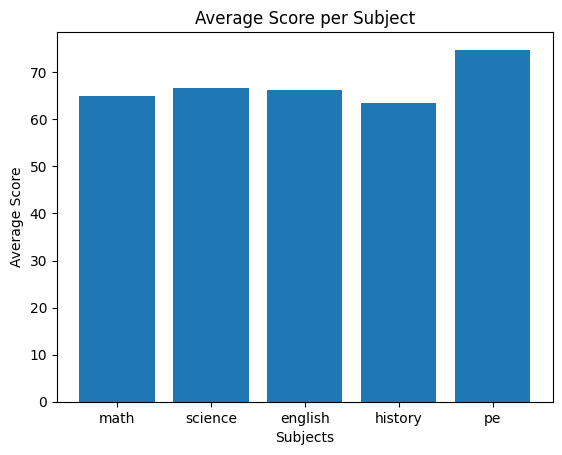

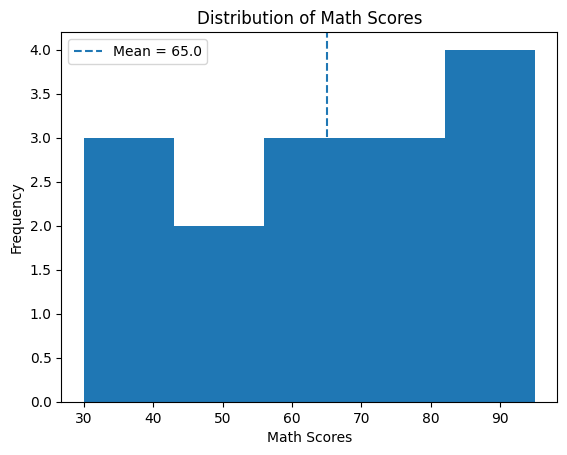

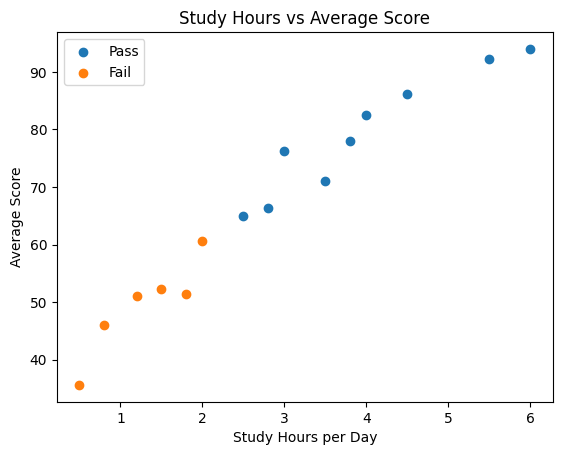

/var/folders/1x/7mlc5c7s3591tltvxnm8knv40000gn/T/ipykernel_3938/150799717.py:132: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


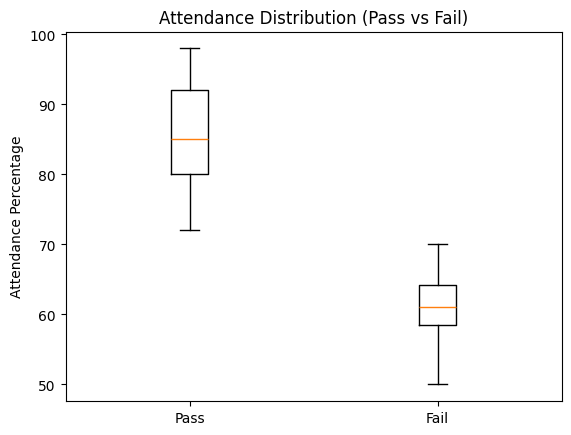

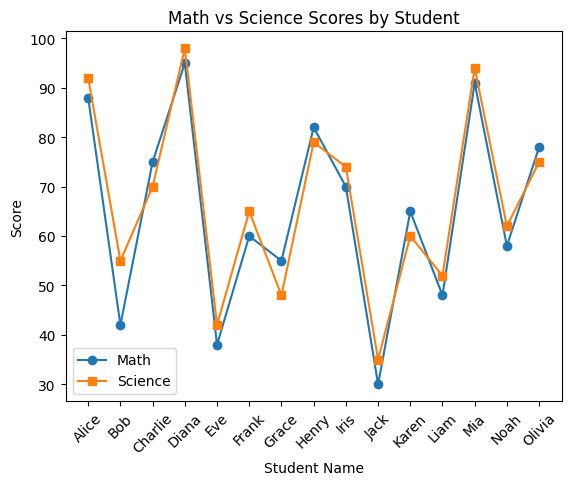

Task 3 — Data Visualization with Seaborn


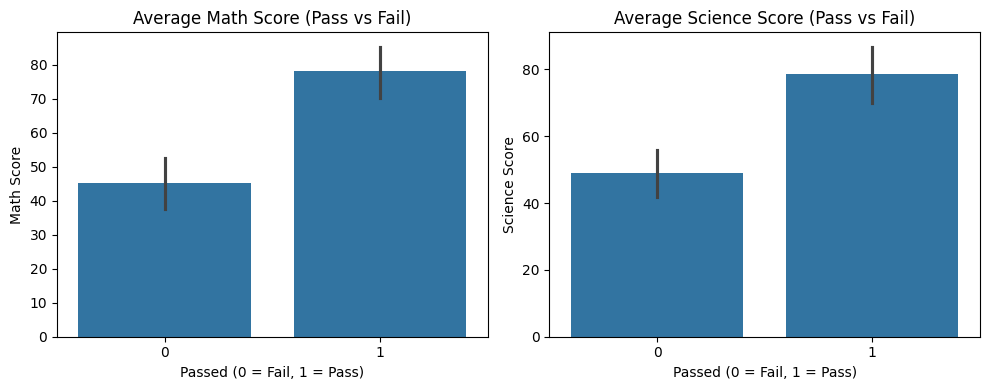

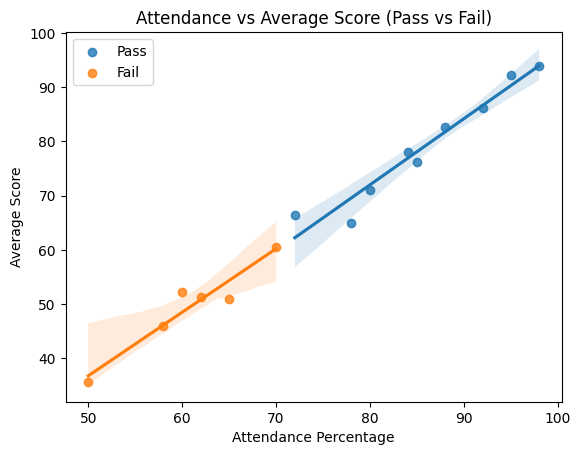

Task 4 — Machine Learning with scikit-learn

Training Accuracy: 1.0

Test Accuracy: 1.0

Test Predictions:
Jack | Actual: 0 | Predicted: 0 | ✅ Correct
Liam | Actual: 0 | Predicted: 0 | ✅ Correct
Alice | Actual: 1 | Predicted: 1 | ✅ Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.475
math: 0.4379
science: 0.323
history: 0.2629


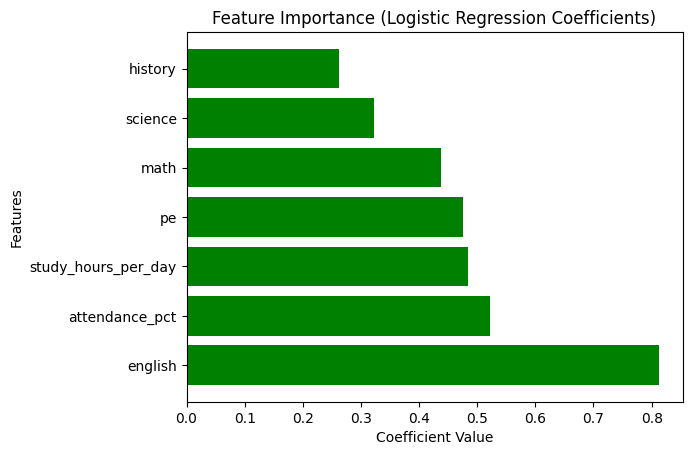


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
# Part 4

import pandas as pd

print("="*50)
print("Task 1 — Data Exploration with Pandas")
print("="*50)

# Part 4 - Task1
# Load dataset
df = pd.read_csv("students.csv")

# Part 4 - Task1.1
print("First 5 rows:")
print(df.head())

# Part 4 - Task1.2
print("Shape (rows, columns):", df.shape)

print("Data Types:")
print(df.dtypes)

# Part 4 - Task1.3
print("Summary Statistics:")
print(df.describe())

# Part 4 - Task1.4
print("Pass/Fail Count:")
print(df['passed'].value_counts())

# Part 4 - Task1.5

subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average Scores (Passed Students):")
print(pass_avg)

print("Average Scores (Failed Students):")
print(fail_avg)

# Part 4 - Task1.6

df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]

print("Top Student:")
print(f"Name: {top_student['name']}")
print(f"Average Score: {round(top_student['avg_score'], 2)}")


#####################################################################################


# Part 4 - Task2

import matplotlib.pyplot as plt

print("="*50)
print("Task 2 — Data Visualization with Matplotlib")
print("="*50)


# Add average score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Part 4 - Task2.1

# Bar Chart — Average score per subject

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

# Part 4 - Task2.2

# Histogram — Distribution of math scores

plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {round(mean_math,2)}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()

# Part 4 - Task2.3

# Scatter Plot — Study hours vs Avg score

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label="Pass")
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

# Part 4 - Task2.4

# Box Plot — Attendance (Pass vs Fail)

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_boxplot.png")
plt.show()

# Part 4 - Task2.5

# Line Plot — Math vs Science scores

plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


#####################################################################################


# Part 4 - Task3

import seaborn as sns

print("="*50)
print("Task 3 — Data Visualization with Seaborn")
print("="*50)

# Load dataset
df = pd.read_csv("students.csv")

# Add average score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Part 4 - Task3.1
# Bar Plot — Math & Science scores (Pass vs Fail)

plt.figure(figsize=(10, 4))

# Subplot 1 → Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2 → Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Part 4 - Task3.2
# Scatter Plot with Regression Line

plt.figure()

# Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

# Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# 3 & 4. Comparison Comment

# Seaborn made it easier to create visually appealing plots with less code,
# especially for grouped comparisons like Pass vs Fail.
# Compared to Matplotlib, Seaborn handles styling and statistical plotting
# (like regression lines) automatically, reducing manual effort.


#####################################################################################


# Part 4 - Task4

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("="*50)
print("Task 4 — Machine Learning with scikit-learn")
print("="*50)

# Load dataset
df = pd.read_csv("students.csv")

# Step 1 — Prepare Data

feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 2 — Train Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)

print("\nTraining Accuracy:", round(train_accuracy, 2))


# Step 3 — Evaluate Model

y_pred = model.predict(X_test_scaled)

test_accuracy = model.score(X_test_scaled, y_test)

print("\nTest Accuracy:", round(test_accuracy, 2))

print("\nTest Predictions:")

test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} | Actual: {actual} | Predicted: {pred} | {result}")


# Step 4 — Feature Importance

coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {round(coef, 4)}")

# Bar chart
features = [f[0] for f in feature_importance]
coefs = [f[1] for f in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
plt.barh(features, coefs, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()


# Step 5 — Predict for New Student (Bonus)

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", result)
print(f"Probability (Fail, Pass): {probability}")